# L5: Fast AI Agents with a Semantic Cache

In this final lab, you’ll integrate your semantic cache into an AI agent so it can reuse past results, skip redundant work, and get faster over time.

<p style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px"> ⏳ <b>Note <code>(Kernel Starting)</code>:</b> This notebook takes about 30 seconds to be ready to use. You may start and watch the video while you wait.</p>

In [1]:
# Warning control
import warnings
warnings.filterwarnings('ignore')

## Setup Environment

In [2]:
from cache.llm_evaluator import set_ark_key

set_ark_key()

In [3]:
import logging
import time
import json
import numpy as np
import pandas as pd
from datetime import datetime
from typing import List, Dict, Any, Optional

from langchain.schema import Document
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langgraph.graph import StateGraph, END, START

import redis
from redisvl.utils.vectorize import HFTextVectorizer, OpenAITextVectorizer
from redisvl.extensions.cache.llm import SemanticCache
from redisvl.index import SearchIndex
from redisvl.query import VectorQuery

logging.basicConfig(
    level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s"
)
logger = logging.getLogger("agentic-workflow")

<div style="background-color:#fff6ff; padding:13px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">
<p> 💻 &nbsp; <b>Access <code>requirements.txt</code> and <code>helper.py</code> files:</b> 1) click on the <em>"File"</em> option on the top menu of the notebook and then 2) click on <em>"Open"</em>.

<p> ⬇ &nbsp; <b>Download Notebooks:</b> 1) click on the <em>"File"</em> option on the top menu of the notebook and then 2) click on <em>"Download as"</em> and select <em>"Notebook (.ipynb)"</em>.</p>
</div>

### Setup API Key and Evaluator

In [4]:
from cache.llm_evaluator import set_ark_key
set_ark_key()

### Build the Agent Knowledge Base (for RAG)


In [6]:
from agent import create_knowledge_base_from_texts


embeddings = HFTextVectorizer(model="sentence-transformers/all-MiniLM-L6-v2")

raw_docs = [
    "Our premium support plan includes 24/7 phone support, priority email response within 2 hours, and dedicated account management. Premium support costs $49/month.",
    "Account upgrade process: Go to Account Settings → Plan & Billing → Select Upgrade. Available plans: Basic $9/month, Pro $29/month, Enterprise $99/month.",
    "API rate limits by plan: Free tier 100 requests/hour, Basic 1,000 requests/hour, Pro 10,000 requests/hour, Enterprise unlimited with fair-use policy.",
    "Data export options: CSV, JSON, XML formats supported. Large exports (>1GB) may take up to 24 hours to process.",
    "Third-party integrations: Native support for Slack, Microsoft Teams, Zoom, Salesforce, HubSpot. 200+ additional integrations available via Zapier.",
    "Security features: SOC2 compliance, end-to-end encryption, GDPR compliance, SSO integration, audit logs, IP whitelisting.",
    "Billing and payments: We accept all major credit cards, PayPal, and ACH transfers. Enterprise customers can pay by invoice with NET30 terms.",
    "Account recovery: Use forgot password link, verify email, or contact support with account verification details. Response within 4 hours.",
]

success, message, kb_index = create_knowledge_base_from_texts(
    texts=raw_docs,
    source_id="customer_support_docs",
    redis_url="redis://localhost:6379",
    skip_chunking=True
)

INFO:sentence_transformers.SentenceTransformer:Use pytorch device_name: mps
INFO:sentence_transformers.SentenceTransformer:Load pretrained SentenceTransformer: sentence-transformers/all-MiniLM-L6-v2
INFO:sentence_transformers.SentenceTransformer:Use pytorch device_name: mps
INFO:sentence_transformers.SentenceTransformer:Load pretrained SentenceTransformer: sentence-transformers/all-MiniLM-L6-v2
INFO:kb-utils:Using provided list of 8 text chunks
INFO:redisvl.index.index:Index already exists, overwriting.
INFO:kb-utils:✅ Created knowledge base with 8 chunks (text_list)


### Build the Semantic Cache

In [7]:
from cache.wrapper import SemanticCacheWrapper
from cache.config import config
from cache.cross_encoder import CrossEncoder
from cache.faq_data_container import FAQDataContainer

cache = SemanticCacheWrapper.from_config(config)

data = FAQDataContainer()
cache.hydrate_from_df(data.faq_df, clear=True)

INFO:sentence_transformers.SentenceTransformer:Use pytorch device_name: mps
INFO:sentence_transformers.SentenceTransformer:Load pretrained SentenceTransformer: redis/langcache-embed-v1


✅ Redis is running and accessible!


INFO:redisvl.index.index:Index already exists, not overwriting.


Loaded 8 FAQ entries
Loaded 80 test queries


## Build the LangGraph Agent

In [8]:
from agent import (
    WorkflowState,
    initialize_agent,
    decompose_query_node,
    check_cache_node,
    research_node,
    evaluate_quality_node,
    synthesize_response_node,
    route_after_cache_check,
    route_after_quality_evaluation,
)

initialize_agent(cache, kb_index, embeddings)

In [9]:
workflow = StateGraph(WorkflowState)

# Add nodes 
workflow.add_node("decompose_query", decompose_query_node)
workflow.add_node("check_cache", check_cache_node)
workflow.add_node("research", research_node)
workflow.add_node("evaluate_quality", evaluate_quality_node)
workflow.add_node("synthesize", synthesize_response_node)

# Set entry point to decomposition node
workflow.set_entry_point("decompose_query")

# Add edges
workflow.add_edge("decompose_query", "check_cache")
workflow.add_conditional_edges(
    "check_cache",
    route_after_cache_check,
    {
        "research": "research",  # Go to research if cache misses
        "synthesize": "synthesize",  # Skip to synthesis if all cached
    },
)
workflow.add_edge("research", "evaluate_quality")
workflow.add_conditional_edges(
    "evaluate_quality",
    route_after_quality_evaluation,
    {
        "research": "research",
        "synthesize": "synthesize",
    },
)
workflow.add_edge("synthesize", END)

workflow_app = workflow.compile()

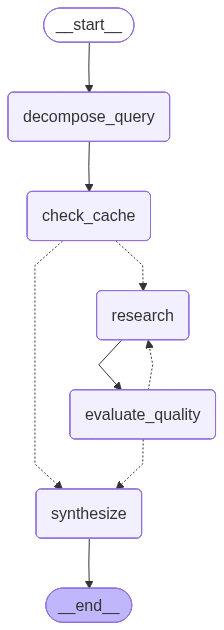

In [10]:
from IPython.display import Image, display

display(Image(workflow_app.get_graph().draw_mermaid_png()))

## Demo the Agent

<p style="background-color:#f7fff8; padding:15px; border-width:3px; border-color:#e0f0e0; border-style:solid; border-radius:6px"> 🚨
&nbsp; <b>Different Run Results:</b> The output visualizations generated may differ from those shown in the video.</p>

In [11]:
from agent import display_results
from agent import run_agent

### Scenario 1: Enterprise Platform Evaluation (cache building phase)


In [12]:
scenario1_query = """
We are evaluating your platform for our enterprise. We need to know the specific
API rate limits for the Enterprise plan, your data export options for a 2GB migration,
the security compliance standards you meet, and if you support ACH payments.
"""

result1 = run_agent(workflow_app, scenario1_query)
display_results(result1)

INFO:agentic-workflow:================================================================================
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
INFO:agentic-workflow:🧠 Decomposing query...
INFO:agentic-workflow:🧠 Supervisor: Decomposing query: '
We are evaluating your platform for our enterpris...'
INFO:httpx:HTTP Request: POST https://ark.cn-beijing.volces.com/api/v3/chat/completions "HTTP/1.1 200 OK"
INFO:agentic-workflow:🧠 Decomposed into 4 sub-questions in 2373.47ms
INFO:agentic-workflow:   1. What are the specific API rate limits for the Enterprise plan?
INFO:agentic-workflow:   2. What data export options are available for a 2GB migration?
INFO:agentic-workflow:   3. Which security compliance standards

\n🎯 SEMANTIC CACHING WORKFLOW ANALYSIS
📝 **Original Query:** 
We are evaluating your platform for our enterprise. We need to know the specific
API rate limits fo...
🔄 **Execution Path:** decomposed → cache_checked → researched → quality_evaluated → researched → quality_evaluated → synthesized
\n🧠 **Query Decomposition:** 4 sub-questions
   1. 🔍 **RESEARCH**: What are the specific API rate limits for the Enterprise plan?
   2. 🔍 **RESEARCH**: What data export options are available for a 2GB migration?
   3. 🔍 **RESEARCH**: Which security compliance standards does the platform meet?
   4. 🔍 **RESEARCH**: Does the platform support ACH payments?
\n📊 **Performance Metrics:**
   💾 Cache Hit Rate: **0.0%** (0/4 questions)
   🤖 LLM Calls: **18** (GPT-4: 2, GPT-4-Mini: 16)
   ⚡ Total Latency: **303736.50ms**
   ⏱️  Cache: 262ms, Research: 136390ms
\n📋 **AI Response:**
--------------------------------------------------------------------------------


Thank you for considering our platform for your enterprise needs. I've gathered the information you requested, and I want to be transparent about what I can confirm directly from our available resources, as well as provide clear next steps for obtaining the specific details you need.

Here’s a summary of what I found:

**API Rate Limits for the Enterprise Plan**  
Our current documentation does not specify detailed API rate limits for the Enterprise plan. Enterprise plans often include customizable or negotiable limits tailored to your usage. I recommend reaching out to our sales or support team for precise, up-to-date information.

**Data Export Options for a 2GB Migration**  
Information on data export options and supported formats (e.g., CSV, JSON, SQL) for migrations of this scale isn’t available in our knowledge base. For a smooth 2GB migration, please consult our technical documentation or contact support to discuss your specific data structure, format compatibility, and transfer methods.

**Security Compliance Standards**  
While our knowledge base doesn’t list specific certifications, we prioritize enterprise-grade security. Common standards we often address include ISO 27001, SOC 2, HIPAA, GDPR, and PCI DSS, depending on your industry. For a detailed compliance report or audit documentation, please contact our security team directly.

**ACH Payment Support**  
I couldn’t confirm ACH payment support from our internal resources. To get a definitive answer—including details on setup, fees, and processing times—please check our official payment processing documentation or reach out to our support team.

**Recommended Next Steps**  
To ensure you have all the accurate, detailed information for your evaluation:

1. **Contact our Enterprise Sales or Support Team**—They can provide customized answers on API limits, migration tools, compliance certifications, and payment methods.
2. **Review our official technical and compliance documentation** available on our website.
3. **Schedule a consultation** to discuss your specific requirements and any custom solutions.

We’re here

--------------------------------------------------------------------------------


### Scenario 2: Implementation Planning (partial cache hits likely)

In [13]:
scenario2_query = """
We're moving forward with implementation planning. I need to compare API rate limits 
between Pro and Enterprise plans to decide on our tier, confirm the Salesforce 
integration capabilities we discussed, understand what data export options you provide 
for our migration needs, and verify the payment methods including ACH since our 
accounting team prefers that for monthly billing.
"""

result2 = run_agent(workflow_app, scenario2_query)
display_results(result2)

INFO:agentic-workflow:================================================================================
INFO:agentic-workflow:🧠 Decomposing query...
INFO:agentic-workflow:🧠 Supervisor: Decomposing query: '
We're moving forward with implementation planning...'
INFO:httpx:HTTP Request: POST https://ark.cn-beijing.volces.com/api/v3/chat/completions "HTTP/1.1 200 OK"
INFO:agentic-workflow:🧠 Decomposed into 4 sub-questions in 2046.23ms
INFO:agentic-workflow:   1. Compare API rate limits between Pro and Enterprise plans.
INFO:agentic-workflow:   2. Confirm Salesforce integration capabilities.
INFO:agentic-workflow:   3. Understand data export options for migration needs.
INFO:agentic-workflow:   4. Verify accepted payment methods, specifically ACH for monthly billing.
INFO:agentic-workflow:🧠 Query decomposition complete
INFO:agentic-workflow:🔍 Supervisor: Checking cache for 4 sub-questions
INFO:agentic-workflow:   ✅ Cache HIT: 'Compare API rate limits between Pro and ...' (confidence: 0.917)


\n🎯 SEMANTIC CACHING WORKFLOW ANALYSIS
📝 **Original Query:** 
We're moving forward with implementation planning. I need to compare API rate limits 
between Pro a...
🔄 **Execution Path:** decomposed → cache_checked → researched → quality_evaluated → researched → quality_evaluated → synthesized
\n🧠 **Query Decomposition:** 4 sub-questions
   1. ✅ **CACHE HIT** (0.917): Compare API rate limits between Pro and Enterprise plans.
   2. 🔍 **RESEARCH**: Confirm Salesforce integration capabilities.
   3. 🔍 **RESEARCH**: Understand data export options for migration needs.
   4. 🔍 **RESEARCH**: Verify accepted payment methods, specifically ACH for monthly billing.
\n📊 **Performance Metrics:**
   💾 Cache Hit Rate: **25.0%** (1/4 questions)
   🤖 LLM Calls: **14** (GPT-4: 2, GPT-4-Mini: 12)
   ⚡ Total Latency: **224275.55ms**
   ⏱️  Cache: 12ms, Research: 101197ms
\n📋 **AI Response:**
--------------------------------------------------------------------------------


Thank you for reaching out with these important questions as you move forward with implementation planning. I’ve gathered the available information for each point, and here’s what I can share to help guide your next steps.

**API Rate Limits – Pro vs. Enterprise Plans**  
Our knowledge base doesn’t list specific API rate limits for Enterprise plans, as these are typically customized during contract negotiations. Enterprise agreements often include tailored rate limits, SLAs, and dedicated support based on your expected usage, peak loads, and business requirements. To get precise details, I recommend contacting our Enterprise sales team directly to discuss your needs and request a custom proposal.

**Salesforce Integration Capabilities**  
I wasn’t able to locate specific details on Salesforce integration features in our resources. For authoritative information on connectors, APIs, and synchronization methods, please refer to official Salesforce documentation or reach out to their support team for technical specifications.

**Data Export Options for Migration**  
While our knowledge base doesn’t have detailed migration guides, Redis generally supports two primary methods:  
- **RDB (Redis Database Backup)**: Provides compact, point-in-time snapshots ideal for fast restores, though it may involve some data loss between snapshots.  
- **AOF (Append-Only File)**: Logs all operations for greater durability and granular recovery, but files can be larger.  
For a smooth migration, consider factors like data volume, downtime tolerance, and whether you need continuous backup. If you have specific migration scenarios in mind, our technical team can provide tailored advice.

**Payment Methods – ACH for Monthly Billing**  
Our resources don’t include details on accepted payment methods, including ACH. To confirm billing options and set up monthly ACH payments as preferred by your accounting team, please check your account’s billing settings or contact our billing support directly. They can assist with payment setup and any related documentation.

**Next Steps**  
To move forward efficiently:  
1.

--------------------------------------------------------------------------------


### Scenario 3: Pre-Purchase Comprehensive Review (many cache hits expected)

In [14]:
scenario3_query = """
Before finalizing our Pro plan purchase, I need complete validation on: your security 
compliance framework including SOC2 requirements, the exact API rate limits for the 
Pro plan we're purchasing, confirmation of the Salesforce integration features, all 
supported payment methods since we want to use ACH transfers, and your data export 
capabilities for our future migration planning.
"""

result3 = run_agent(workflow_app, scenario3_query)
display_results(result3)

INFO:agentic-workflow:================================================================================
INFO:agentic-workflow:🧠 Decomposing query...
INFO:agentic-workflow:🧠 Supervisor: Decomposing query: '
Before finalizing our Pro plan purchase, I need c...'
INFO:httpx:HTTP Request: POST https://ark.cn-beijing.volces.com/api/v3/chat/completions "HTTP/1.1 200 OK"
INFO:agentic-workflow:🧠 Decomposed into 4 sub-questions in 3789.63ms
INFO:agentic-workflow:   1. Security compliance framework and SOC2 requirements for the Pro plan.
INFO:agentic-workflow:   2. Exact API rate limits for the Pro plan.
INFO:agentic-workflow:   3. Confirmation of Salesforce integration features for the Pro plan.
INFO:agentic-workflow:   4. Supported payment methods, specifically ACH transfer availability.
INFO:agentic-workflow:🧠 Query decomposition complete
INFO:agentic-workflow:🔍 Supervisor: Checking cache for 4 sub-questions
INFO:agentic-workflow:   ❌ Cache MISS: 'Security compliance framework and SOC2 r...'
IN

\n🎯 SEMANTIC CACHING WORKFLOW ANALYSIS
📝 **Original Query:** 
Before finalizing our Pro plan purchase, I need complete validation on: your security 
compliance f...
🔄 **Execution Path:** decomposed → cache_checked → researched → quality_evaluated → researched → quality_evaluated → synthesized
\n🧠 **Query Decomposition:** 4 sub-questions
   1. 🔍 **RESEARCH**: Security compliance framework and SOC2 requirements for the Pro plan.
   2. ✅ **CACHE HIT** (0.894): Exact API rate limits for the Pro plan.
   3. ✅ **CACHE HIT** (0.901): Confirmation of Salesforce integration features for the Pro plan.
   4. ✅ **CACHE HIT** (0.865): Supported payment methods, specifically ACH transfer availability.
\n📊 **Performance Metrics:**
   💾 Cache Hit Rate: **75.0%** (3/4 questions)
   🤖 LLM Calls: **6** (GPT-4: 2, GPT-4-Mini: 4)
   ⚡ Total Latency: **89088.92ms**
   ⏱️  Cache: 6ms, Research: 33221ms
\n📋 **AI Response:**
--------------------------------------------------------------------------------


Thank you for reaching out with these important questions before finalizing your Pro plan purchase. I've gathered the details you requested, and I'll provide a clear summary of what we can confirm, along with guidance on the items that require further action.

Here’s a breakdown based on your query:

### 🔒 Security Compliance (SOC2) for the Pro Plan
After a thorough review of our available documentation, I must inform you that specific details regarding SOC2 compliance for the Pro plan are not currently listed in our public knowledge base. This type of compliance information is often detailed in formal agreements or direct communications.  
**Recommended Action:** To get a definitive answer and any applicable documentation, please contact our Sales or Security team directly. They can provide official compliance statements, reports, or clarify if SOC2 is included with the Pro tier.

### ⚙️ API Rate Limits for the Pro Plan
Similarly, exact API rate limits for the Pro plan are not publicly specified in our standard documentation. Rate limits, especially for our Pro and Enterprise plans, are typically customized based on your expected usage, peak loads, and specific business needs.  
**Recommended Action:** I encourage you to discuss your anticipated API call volume and performance requirements with our Sales team. They can outline tailored rate limits as part of your proposal.

### 🔗 Salesforce Integration Features
Our knowledge base does not contain detailed, evidence-based information on Salesforce integration capabilities for the Pro plan. Integration features can vary, and accurate, up-to-date specifications are best obtained from official sources.  
**Recommended Action:** For a complete confirmation of supported Salesforce integration features—such as available connectors, API methods, or sync capabilities—please connect with our Sales or Technical Support team. They can provide the specific details relevant to your use case.

### 💳 Supported Payment Methods, Including ACH
I can confirm that we accept a variety of payment methods: all major credit cards (Visa, Mastercard, American Express, etc.), PayPal, Apple Pay

--------------------------------------------------------------------------------


## Agent Performance Analysis


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
INFO:matplotlib.font_manager:Failed to extract font properties from /System/Library/PrivateFrameworks/FontServices.framework/Resources/Reserved/PingFangUI.ttc: Can not load face (locations (loca) table missing; error code 0x90)
INFO:matplotlib.font_manager:Failed to extract font properties from /System/Library/Fonts/Apple Color Emoji.ttc: Could not s

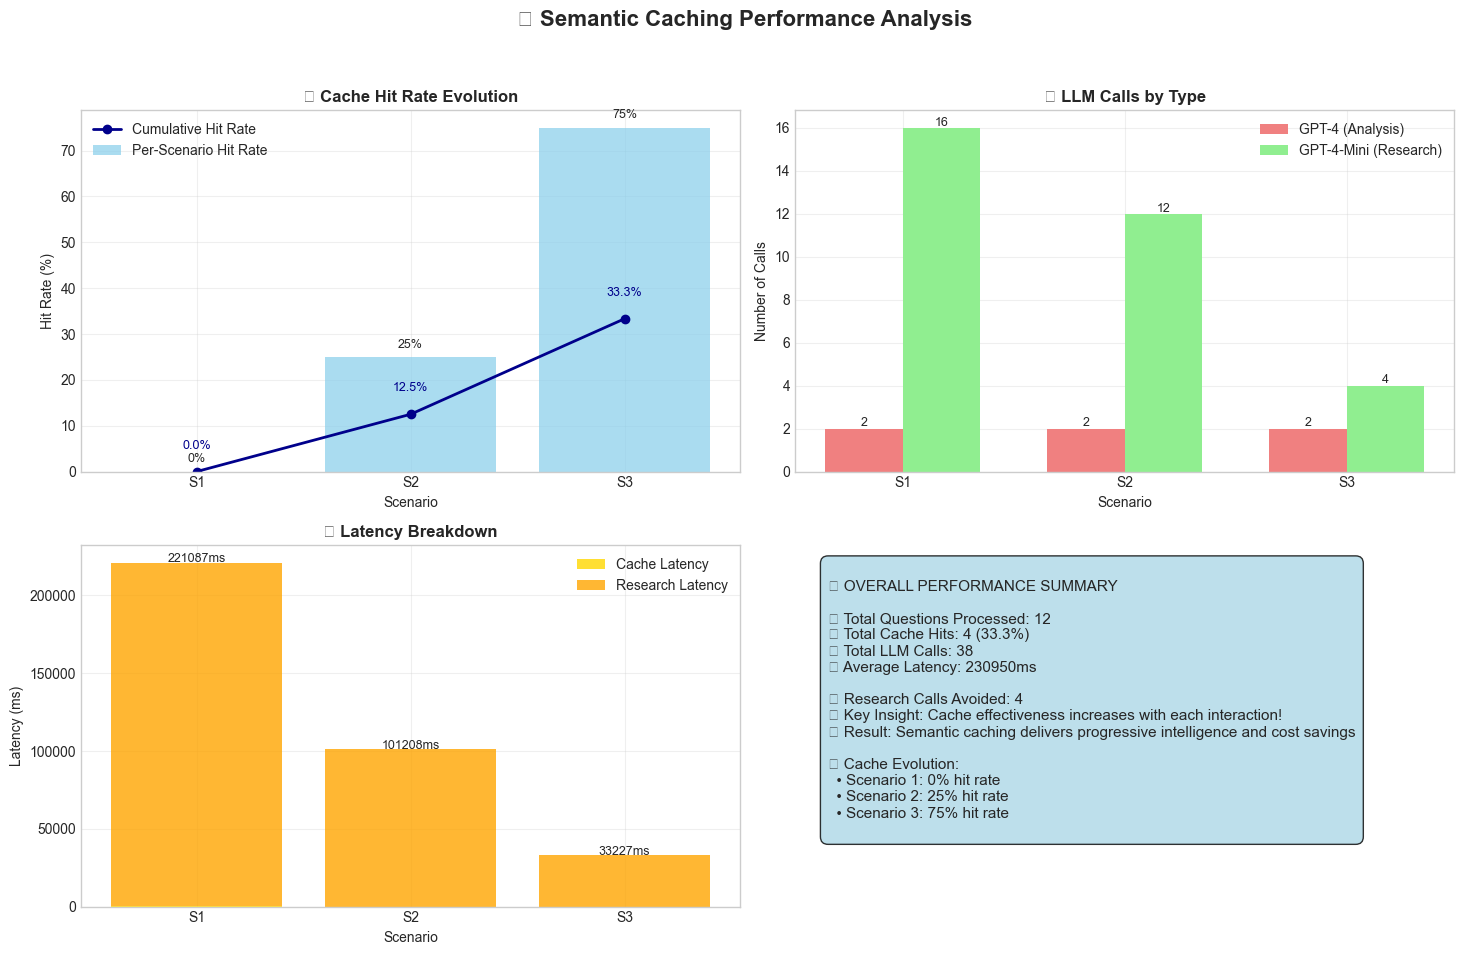

In [15]:
import warnings
warnings.simplefilter("ignore")

from agent import analyze_agent_results

total_questions, total_cache_hits = analyze_agent_results(
    [result1, result2, result3]
)

## Interactive Demo


Here is the link we used in the video for this section:
* https://att.com/international

In [16]:
from agent import launch_demo

launch_demo(
    workflow_app,
    cache,
    share=True,
    height=1500,
    inline=True
)

INFO:demo:Using Tavily API key from environment
INFO:sentence_transformers.SentenceTransformer:Use pytorch device_name: mps
INFO:sentence_transformers.SentenceTransformer:Load pretrained SentenceTransformer: sentence-transformers/all-MiniLM-L6-v2
INFO:httpx:HTTP Request: GET http://127.0.0.1:7860/gradio_api/startup-events "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD http://127.0.0.1:7860/ "HTTP/1.1 200 OK"


* Running on local URL:  http://127.0.0.1:7860


INFO:httpx:HTTP Request: GET https://api.gradio.app/v3/tunnel-request "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://api.gradio.app/pkg-version "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://cdn-media.huggingface.co/frpc-gradio-0.3/frpc_darwin_arm64 "HTTP/1.1 200 OK"
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


* Running on public URL: https://e01f87ec5b8084b8c8.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


INFO:httpx:HTTP Request: HEAD https://e01f87ec5b8084b8c8.gradio.live "HTTP/1.1 200 OK"


In [17]:
cache.cache.check(
    "checking cache", distance_threshold=1.0, num_results=100
)

[{'entry_id': '44b70528690c70dfbfe77f5a872f43f743e5898d208260015d6759aa597cc18a',
  'prompt': 'Verify accepted payment methods, specifically ACH for monthly billing.',
  'response': 'Based on my thorough research using multiple specific search approaches, I can provide a definitive answer:\n\n## Research Results\n\n**Definitive Answer:** **NO INFORMATION FOUND** in the knowledge base regarding accepted payment methods, specifically ACH for monthly billing.\n\n## Specific Searches Performed\n\nI conducted the following targeted searches within the knowledge base to verify payment method information:\n\n1. **Direct ACH-related searches:**\n   - "ACH payment monthly billing accepted methods"\n   - "bank transfer direct debit recurring payment"\n\n2. **Payment method documentation searches:**\n   - "payment methods billing subscription terms of service"\n   - "credit card PayPal Stripe payment gateway"\n\n3. **Help/support documentation searches:**\n   - "help pages billing FAQ payment opt